CONDITIONAL GRAPH

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
class AgentState(TypedDict):
    number1:int
    number2:int
    operation:str
    result:int

def adder_node(state:AgentState)->AgentState:
    """This node adds 2 numbers"""
    state["result"] = state["number1"] + state["number2"]
    return state

def subtractor_node(state:AgentState)->AgentState:
    """This node subtracts 2 numbers"""
    state["result"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state:AgentState)->AgentState:
    """This node routes to the correct node."""
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"
    


In [12]:
graph = StateGraph(AgentState)

graph.add_node("router",lambda state:state)
graph.add_node("adder_node", adder_node)
graph.add_node("subtractor_node", subtractor_node)
graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "addition_operation":"adder_node",
        "subtraction_operation":"subtractor_node"
    },

)
graph.add_edge("adder_node", END)
graph.add_edge("subtractor_node",END)

app = graph.compile()


In [14]:
answer = app.invoke({"number1":30,"number2":5,"operation":"-"})
print(answer)

{'number1': 30, 'number2': 5, 'operation': '-', 'result': 25}


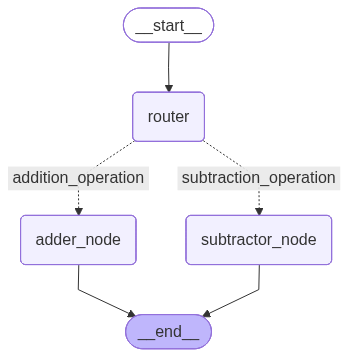

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))